In [ ]:
!pip install tensorflow-cpu

In [2]:
import pandas as pd
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

In [4]:
tracks = pd.read_csv(
    r'C:\Users\Srikanth\srihome\project\data\fma_metadata\tracks.csv',
    index_col=0, header=[0, 1]
)

small = tracks[tracks['set', 'subset'] == 'small']

print("Number of tracks in FMA small:", len(small))
print("Genres:")
print(small['track', 'genre_top'].value_counts())

Number of tracks in FMA small: 8000
Genres:
(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [20]:
import time
import pickle

SR = 22050
N_MELS = 64
CHUNK_SEC = 6
CHUNK_SAMPLES = SR * CHUNK_SEC
HOP_SEC = 6  # 50% overlap between chunks

CACHE_DIR = r"C:\Users\Srikanth\srihome\project\data\cnn_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def get_chunk_specs(file_path, max_chunks=3):
    y, sr = librosa.load(file_path, sr=SR, mono=True)

    chunks = []
    step = int(HOP_SEC * SR)
    win = CHUNK_SAMPLES

    for start in range(0, max(len(y) - win, 1), step):
        if len(chunks) >= max_chunks:
            break
        segment = y[start:start + win]
        if len(segment) < win:
            segment = np.pad(segment, (0, win - len(segment)))

        S = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=N_MELS)
        S_db = librosa.power_to_db(S, ref=np.max)
        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
        chunks.append(S_db)

    return chunks


def augment_pitch_chunk(y_segment, sr):
    n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y=y_segment, sr=sr, n_steps=n_steps)

In [21]:
# build chunks per split and saves progress to disk every N tracks, crash safe

def build_chunks_for_split(split_name, track_ids_genres, augment_fraction=0.3):
    cache_file = os.path.join(CACHE_DIR, f"{split_name}_chunks.pkl")
    log_file = os.path.join(CACHE_DIR, f"{split_name}_failed.txt")

    # resume if cache already exists
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            data = pickle.load(f)
        done_ids = set(data["done_ids"])
        X = data["X"]
        y = data["y"]
        print(f"[{split_name}] resuming, already done: {len(done_ids)} tracks")
    else:
        done_ids = set()
        X = []
        y = []

    total = len(track_ids_genres)
    start_time = time.time()

    for i, (track_id, genre) in enumerate(track_ids_genres):
        if track_id in done_ids:
            continue

        tid = f"{int(track_id):06d}"
        subfolder = tid[:3]
        file_path = os.path.join(audio_root, subfolder, f"{tid}.mp3")

        if not os.path.exists(file_path):
            with open(log_file, "a") as f:
                f.write(f"{track_id},missing\n")
            done_ids.add(track_id)
            continue

        try:
            chunks = get_chunk_specs(file_path)

            for c in chunks:
                X.append(c)
                y.append(genre)

            # add augmented chunks only for training split, only a fraction of files
            if split_name == "train" and np.random.rand() < augment_fraction:
                y_raw, sr = librosa.load(file_path, sr=SR, mono=True)
                y_aug = augment_pitch_chunk(y_raw, sr)
                S = librosa.feature.melspectrogram(y=y_aug[:CHUNK_SAMPLES], sr=sr, n_mels=N_MELS)
                S_db = librosa.power_to_db(S, ref=np.max)
                if S_db.shape[1] > 0:
                    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
                    X.append(S_db)
                    y.append(genre)

            done_ids.add(track_id)

        except Exception as e:
            with open(log_file, "a") as f:
                f.write(f"{track_id},{str(e)}\n")
            done_ids.add(track_id)
            continue

        # save progress every 200 tracks so we never lose more than that on a crash
        if (i + 1) % 200 == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            remaining = (total - i - 1) / rate if rate > 0 else 0
            print(f"[{split_name}] {i+1}/{total} tracks | chunks so far: {len(X)} | "
                  f"elapsed {elapsed/60:.1f} min | est. remaining {remaining/60:.1f} min")

            with open(cache_file, "wb") as f:
                pickle.dump({"X": X, "y": y, "done_ids": list(done_ids)}, f)

    # final save
    with open(cache_file, "wb") as f:
        pickle.dump({"X": X, "y": y, "done_ids": list(done_ids)}, f)

    print(f"[{split_name}] DONE. Total chunks: {len(X)}")
    return np.array(X), y


train_ids = [(tid, row[('track', 'genre_top')]) for tid, row in small.iterrows()
             if row[('set', 'split')] == 'training']
valid_ids = [(tid, row[('track', 'genre_top')]) for tid, row in small.iterrows()
             if row[('set', 'split')] == 'validation']
test_ids  = [(tid, row[('track', 'genre_top')]) for tid, row in small.iterrows()
             if row[('set', 'split')] == 'test']

print("Train tracks:", len(train_ids))
print("Valid tracks:", len(valid_ids))
print("Test tracks:", len(test_ids))

Train tracks: 6400
Valid tracks: 800
Test tracks: 800


In [9]:
X_train, y_train = build_chunks_for_split("train", train_ids, augment_fraction=0.3)

[train] 200/6400 tracks | chunks so far: 1728 | elapsed 1.5 min | est. remaining 45.0 min
[train] 400/6400 tracks | chunks so far: 3488 | elapsed 2.8 min | est. remaining 42.3 min
[train] 600/6400 tracks | chunks so far: 5225 | elapsed 4.1 min | est. remaining 40.1 min
[train] 800/6400 tracks | chunks so far: 6990 | elapsed 5.6 min | est. remaining 39.1 min
[train] 1000/6400 tracks | chunks so far: 8736 | elapsed 7.0 min | est. remaining 37.6 min
[train] 1200/6400 tracks | chunks so far: 10491 | elapsed 8.6 min | est. remaining 37.1 min
[train] 1400/6400 tracks | chunks so far: 12246 | elapsed 10.2 min | est. remaining 36.3 min
[train] 1600/6400 tracks | chunks so far: 14004 | elapsed 11.8 min | est. remaining 35.4 min
[train] 1800/6400 tracks | chunks so far: 15759 | elapsed 13.5 min | est. remaining 34.5 min
[train] 2000/6400 tracks | chunks so far: 17509 | elapsed 15.2 min | est. remaining 33.5 min
[train] 2200/6400 tracks | chunks so far: 19248 | elapsed 16.9 min | est. remaining 3

In [10]:
X_valid, y_valid = build_chunks_for_split("valid", valid_ids, augment_fraction=0.0)

[valid] 200/800 tracks | chunks so far: 1689 | elapsed 1.7 min | est. remaining 5.2 min
[valid] 400/800 tracks | chunks so far: 3365 | elapsed 3.4 min | est. remaining 3.4 min
[valid] 600/800 tracks | chunks so far: 5049 | elapsed 4.8 min | est. remaining 1.6 min
[valid] 800/800 tracks | chunks so far: 6744 | elapsed 6.1 min | est. remaining 0.0 min
[valid] DONE. Total chunks: 6744


In [12]:
X_test, y_test = build_chunks_for_split("test", test_ids, augment_fraction=0.0)

print("Train chunks:", X_train.shape)
print("Valid chunks:", X_valid.shape)
print("Test chunks:", X_test.shape)

[test] 200/800 tracks | chunks so far: 1690 | elapsed 1.4 min | est. remaining 4.3 min
[test] 400/800 tracks | chunks so far: 3381 | elapsed 2.7 min | est. remaining 2.7 min
[test] 600/800 tracks | chunks so far: 5063 | elapsed 4.0 min | est. remaining 1.3 min
[test] 800/800 tracks | chunks so far: 6764 | elapsed 5.4 min | est. remaining 0.0 min
[test] DONE. Total chunks: 6764
Train chunks: (55732, 128, 259)
Valid chunks: (6744, 128, 259)
Test chunks: (6764, 128, 259)


In [13]:
X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)

y_train_oh = tf.keras.utils.to_categorical(y_train_enc, num_classes)
y_valid_oh = tf.keras.utils.to_categorical(y_valid_enc, num_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test_enc, num_classes)

print("Classes:", le.classes_)
print("Input shape:", X_train.shape[1:])

Classes: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Input shape: (128, 259, 1)


In [14]:
def create_vgg_like_model(input_shape, num_output_dim):
    inp = tf.keras.layers.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding='same')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    out = tf.keras.layers.Dense(num_output_dim, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=inp, outputs=out)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


input_shape = X_train.shape[1:]
model = create_vgg_like_model(input_shape, num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 259, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 259, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 129, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,648 (502.53 KB)

 Trainable params: 128,200 (500.78 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
import time

class TimeTracker(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.start
        remaining_epochs = self.params['epochs'] - (epoch + 1)
        est_remaining = elapsed * remaining_epochs
        print(f"Epoch {epoch+1} took {elapsed/60:.1f} min | est. remaining: {est_remaining/60:.1f} min")


checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'cnn_genre_model_best.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

csv_logger = tf.keras.callbacks.CSVLogger('training_log.csv', append=True)
time_tracker = TimeTracker()

try:
    history = model.fit(
        X_train, y_train_oh,
        validation_data=(X_valid, y_valid_oh),
        batch_size=128,
        epochs=8,
        callbacks=[checkpoint, reduce_lr, early_stop, csv_logger, time_tracker],
        verbose=2
    )
except Exception as e:
    print("Training stopped early due to error:", e)
    model.save('cnn_genre_model_interrupted.keras')
    print("Saved current model state before exiting.")

Epoch 1/8

Epoch 1: val_accuracy improved from None to 0.21693, saving model to cnn_genre_model_best.keras

Epoch 1: finished saving model to cnn_genre_model_best.keras
Epoch 1 took 20.9 min | est. remaining: 146.3 min
436/436 - 1254s - 3s/step - accuracy: 0.4739 - loss: 1.5054 - val_accuracy: 0.2169 - val_loss: 2.5333 - learning_rate: 0.0010
Epoch 2/8

Epoch 2: val_accuracy improved from 0.21693 to 0.45522, saving model to cnn_genre_model_best.keras

Epoch 2: finished saving model to cnn_genre_model_best.keras
Epoch 2 took 21.0 min | est. remaining: 125.7 min
436/436 - 1257s - 3s/step - accuracy: 0.5300 - loss: 1.3569 - val_accuracy: 0.4552 - val_loss: 1.4622 - learning_rate: 0.0010
Epoch 3/8

Epoch 3: val_accuracy did not improve from 0.45522
Epoch 3 took 20.7 min | est. remaining: 103.3 min
436/436 - 1239s - 3s/step - accuracy: 0.5542 - loss: 1.2987 - val_accuracy: 0.4456 - val_loss: 1.6012 - learning_rate: 0.0010
Epoch 4/8

Epoch 4: val_accuracy did not improve from 0.45522

Epoch 

In [24]:
best_model = tf.keras.models.load_model('cnn_genre_model_best.keras')
print("Best model loaded successfully.")

Best model loaded successfully.


In [26]:
y_test_pred_prob = best_model.predict(X_test)
y_test_pred_enc = np.argmax(y_test_pred_prob, axis=1)
y_test_pred = le.inverse_transform(y_test_pred_enc)

test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy (Top-1, chunk level):", test_acc)

212/212 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step
Test accuracy (Top-1, chunk level): 0.49098166765227674


Classification report (per genre):
               precision    recall  f1-score   support

   Electronic      0.683     0.498     0.576       843
 Experimental      0.389     0.352     0.370       842
         Folk      0.280     0.257     0.268       846
      Hip-Hop      0.737     0.737     0.737       841
 Instrumental      0.397     0.619     0.484       847
International      0.567     0.551     0.559       847
          Pop      0.322     0.345     0.334       851
         Rock      0.673     0.570     0.617       847

     accuracy                          0.491      6764
    macro avg      0.506     0.491     0.493      6764
 weighted avg      0.506     0.491     0.493      6764



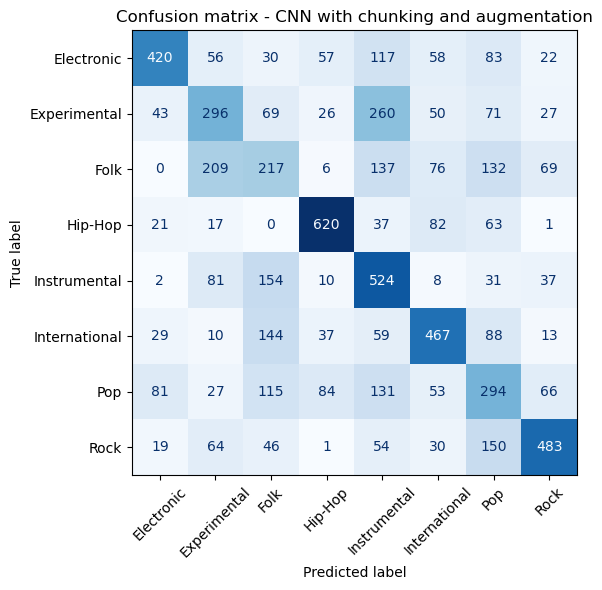

In [27]:
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

print("Classification report (per genre):")
print(classification_report(y_test, y_test_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion matrix - CNN with chunking and augmentation")
plt.tight_layout()
plt.show()

In [29]:

print(f"CNN test accuracy (chunk level): {test_acc:.4f}")


CNN test accuracy (chunk level): 0.4910


Summary of changes compared to previous baselines:
1. Tracks split into 6 second overlapping chunks instead of full 30 second clips
2. Pitch shift augmentation applied to 30 percent of training tracks
3. ModelCheckpoint saves only the best validation accuracy epoch
4. ReduceLROnPlateau lowers learning rate when validation loss stalls
5. EarlyStopping prevents wasted epochs and restores best weights
6. Feature extraction is cached to disk and resumable if interrupted

CNN test accuracy (chunk level): 0.4910
Baseline Random Forest test accuracy was 0.3425 for comparison.